# **1. Perkenalan Dataset**

**Dataset:** Titanic - Machine Learning from Disaster

**Sumber:** [Kaggle Titanic Competition](https://www.kaggle.com/c/titanic/data)

Dataset ini berisi data penumpang kapal Titanic, dengan target untuk memprediksi apakah seorang penumpang selamat (`Survived`) berdasarkan fitur-fitur seperti kelas tiket, jenis kelamin, umur, jumlah saudara/pasangan, jumlah orang tua/anak, harga tiket, kabin, dan pelabuhan keberangkatan.

**Deskripsi Kolom:**
- `PassengerId`: ID unik penumpang
- `Survived`: Target (0 = Tidak selamat, 1 = Selamat)
- `Pclass`: Kelas tiket (1 = 1st, 2 = 2nd, 3 = 3rd)
- `Name`: Nama penumpang
- `Sex`: Jenis kelamin
- `Age`: Umur (tahun)
- `SibSp`: Jumlah saudara/pasangan di kapal
- `Parch`: Jumlah orang tua/anak di kapal
- `Ticket`: Nomor tiket
- `Fare`: Harga tiket
- `Cabin`: Nomor kabin
- `Embarked`: Pelabuhan keberangkatan (C = Cherbourg, Q = Queenstown, S = Southampton)

# **2. Import Library**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

# **3. Memuat Dataset**

In [2]:
RAW_PATH = '../data_titanic_raw/train.csv'
df = pd.read_csv(RAW_PATH)
print('Shape:', df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


# **4. Exploratory Data Analysis (EDA)**

Tujuan EDA adalah untuk memperoleh wawasan awal mengenai data: distribusi, missing values, outlier, korelasi antar fitur, serta pola-pola penting yang berkaitan dengan target `Survived`.

## 4.1. Cek Missing Values

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing': missing, 'percent': missing_pct})
missing_df[missing_df['missing'] > 0]

,missing,percent
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


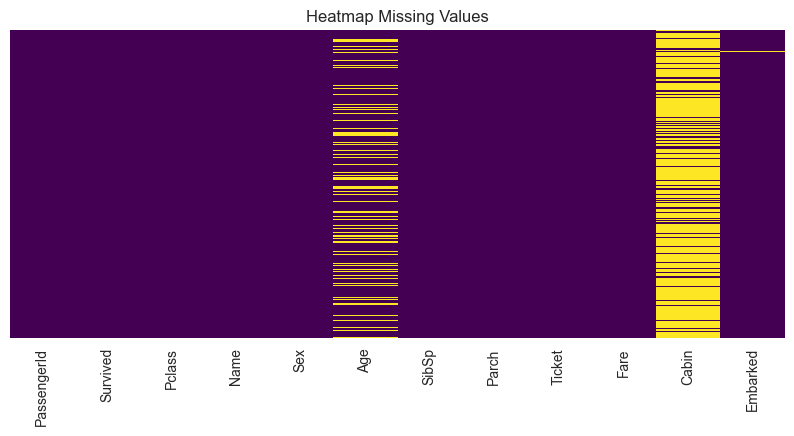

In [6]:
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Heatmap Missing Values')
plt.show()

## 4.2. Cek Duplikasi

In [7]:
print('Jumlah duplikat:', df.duplicated().sum())

Jumlah duplikat: 0


## 4.3. Distribusi Target

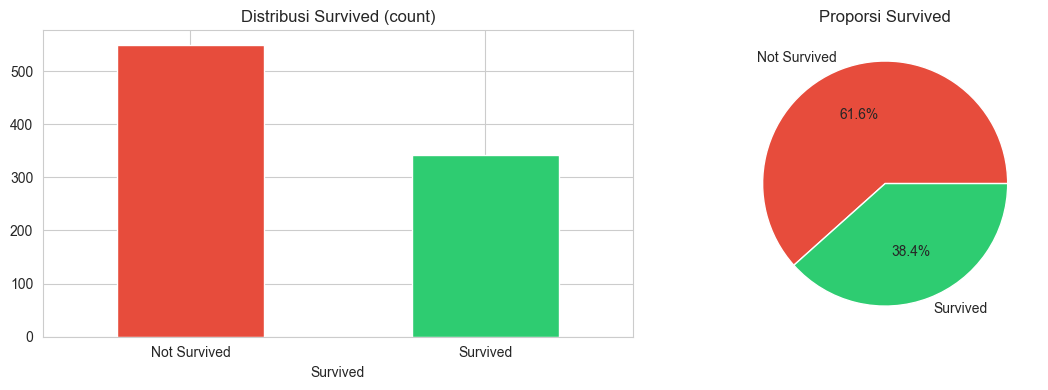

In [8]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
df['Survived'].value_counts().plot(kind='bar', ax=ax[0], color=['#e74c3c','#2ecc71'])
ax[0].set_title('Distribusi Survived (count)')
ax[0].set_xticklabels(['Not Survived','Survived'], rotation=0)
df['Survived'].value_counts(normalize=True).plot(kind='pie', autopct='%.1f%%', ax=ax[1], labels=['Not Survived','Survived'], colors=['#e74c3c','#2ecc71'])
ax[1].set_ylabel('')
ax[1].set_title('Proporsi Survived')
plt.tight_layout()
plt.show()

## 4.4. Distribusi Fitur Numerik

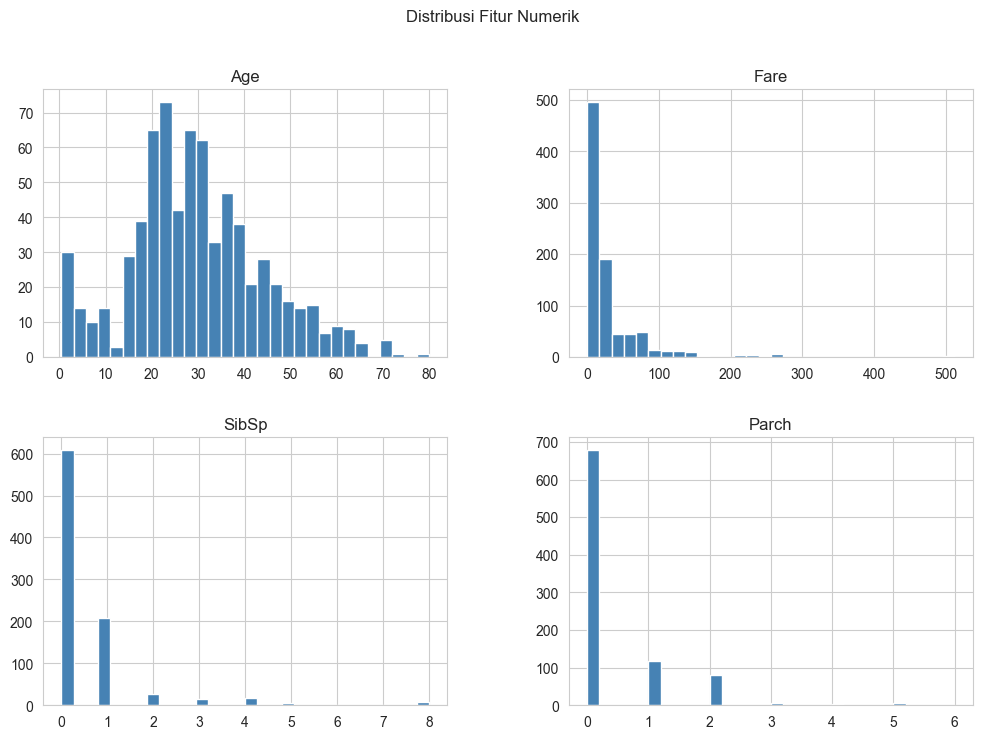

In [9]:
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
df[num_cols].hist(bins=30, figsize=(12,8), color='steelblue')
plt.suptitle('Distribusi Fitur Numerik')
plt.show()

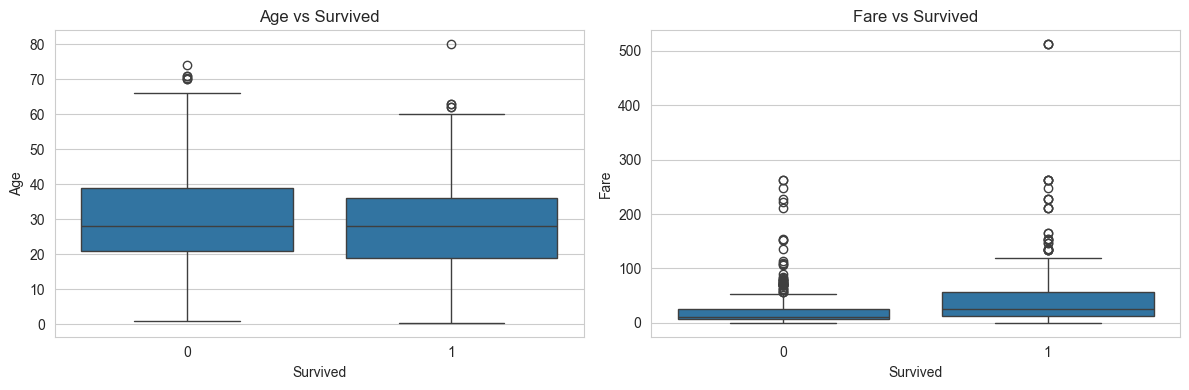

In [10]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.boxplot(x='Survived', y='Age', data=df, ax=ax[0])
ax[0].set_title('Age vs Survived')
sns.boxplot(x='Survived', y='Fare', data=df, ax=ax[1])
ax[1].set_title('Fare vs Survived')
plt.tight_layout()
plt.show()

## 4.5. Distribusi Fitur Kategorikal

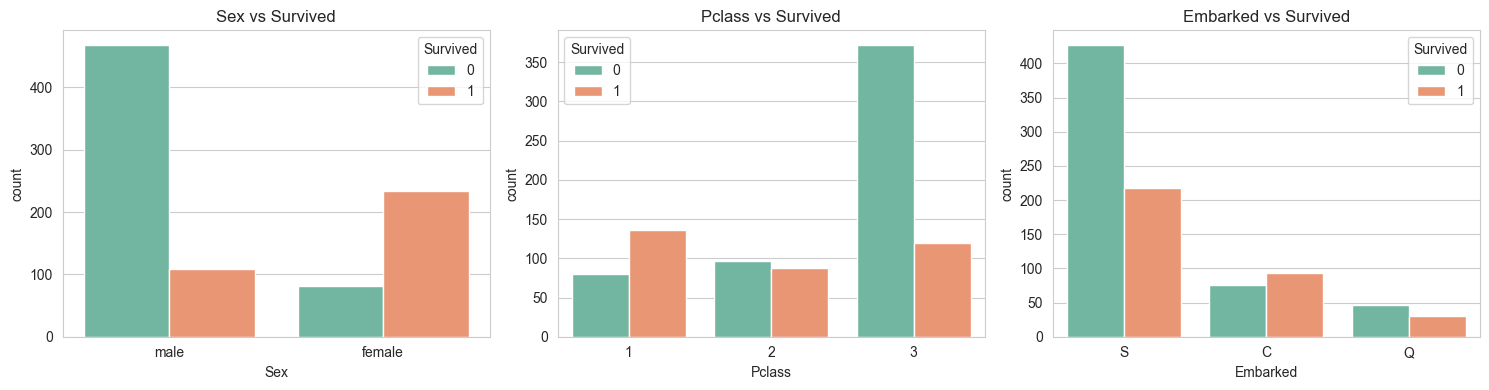

In [11]:
cat_cols = ['Sex', 'Pclass', 'Embarked']
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Survived', data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Survived')
plt.tight_layout()
plt.show()

## 4.6. Korelasi Antar Fitur Numerik

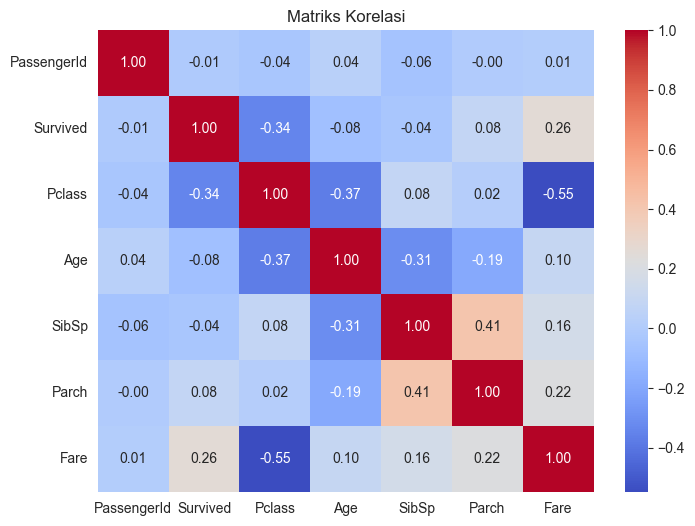

In [12]:
plt.figure(figsize=(8,6))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi')
plt.show()

**Insight EDA:**
- Kolom `Cabin` memiliki missing values >70% sehingga akan didrop.
- Kolom `Age` memiliki missing ~20% akan diisi median.
- Kolom `Embarked` memiliki 2 missing akan diisi modus.
- `Sex` dan `Pclass` adalah prediktor kuat: wanita dan kelas 1 jauh lebih banyak yang selamat.
- `Fare` memiliki outlier yang cukup ekstrem → akan ditangani dengan IQR capping.
- `Name` dan `Ticket` akan didrop (noise tinggi), tetapi `Title` diekstrak dari Name sebagai fitur baru.
- `SibSp` dan `Parch` digabung menjadi `FamilySize`.

# **5. Data Preprocessing**

Tahapan preprocessing yang akan dilakukan:
1. **Menangani Missing Values** (`Age` → median, `Embarked` → modus, `Cabin` → drop).
2. **Menghapus Duplikat**.
3. **Feature Engineering** (`Title` dari `Name`, `FamilySize` dari `SibSp+Parch+1`, `IsAlone`).
4. **Drop kolom yang tidak relevan** (`PassengerId`, `Name`, `Ticket`, `Cabin`).
5. **Encoding Kategorikal** (`Sex`, `Embarked`, `Title` → Label/One-Hot Encoding).
6. **Penanganan Outlier** dengan IQR capping pada `Fare`.
7. **Standarisasi Fitur Numerik** (`Age`, `Fare`, `FamilySize`) dengan `StandardScaler`.
8. **Split data** (train/test 80/20).

In [13]:
data = df.copy()

# 1. Missing values
data['Age'] = data['Age'].fillna(data['Age'].median())
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
data = data.drop(columns=['Cabin'])

# 2. Duplikat
data = data.drop_duplicates().reset_index(drop=True)

# 3. Feature engineering
data['Title'] = data['Name'].str.extract(r',\s*([^\.]+)\.')
title_map = {
    'Mr':'Mr', 'Miss':'Miss', 'Mrs':'Mrs', 'Master':'Master',
    'Dr':'Rare','Rev':'Rare','Col':'Rare','Major':'Rare','Mlle':'Miss',
    'Countess':'Rare','Ms':'Miss','Lady':'Rare','Jonkheer':'Rare',
    'Don':'Rare','Dona':'Rare','Mme':'Mrs','Capt':'Rare','Sir':'Rare'
}
data['Title'] = data['Title'].map(title_map).fillna('Rare')

data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

# 4. Drop kolom non-informatif
data = data.drop(columns=['PassengerId','Name','Ticket'])
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,Mr,2,0
1,1,1,female,38.0,1,0,71.2833,C,Mrs,2,0
2,1,3,female,26.0,0,0,7.9250,S,Miss,1,1
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2,0
4,0,3,male,35.0,0,0,8.0500,S,Mr,1,1


In [14]:
# 5. Encoding kategorikal
data['Sex'] = data['Sex'].map({'male':0,'female':1})
data = pd.get_dummies(data, columns=['Embarked','Title'], drop_first=True)

# Konversi boolean dummy ke int
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,0,22.0,1,0,7.2500,2,0,0,1,0,1,0,0
1,1,1,1,38.0,1,0,71.2833,2,0,0,0,0,0,1,0
2,1,3,1,26.0,0,0,7.9250,1,1,0,1,1,0,0,0
3,1,1,1,35.0,1,0,53.1000,2,0,0,1,0,0,1,0
4,0,3,0,35.0,0,0,8.0500,1,1,0,1,0,1,0,0


In [15]:
# 6. Penanganan outlier (Fare) dengan IQR capping
Q1 = data['Fare'].quantile(0.25)
Q3 = data['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
data['Fare'] = data['Fare'].clip(lower=lower, upper=upper)
print('Fare bounds:', lower, upper)

Fare bounds: -26.724 65.6344


In [16]:
# 7. Standarisasi fitur numerik
scaler = StandardScaler()
num_features = ['Age','Fare','FamilySize','SibSp','Parch']
data[num_features] = scaler.fit_transform(data[num_features])
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,0,-0.565736,0.432793,-0.473674,-0.820552,0.059160,0,0,1,0,1,0,0
1,1,1,1,0.663861,0.432793,-0.473674,2.031623,0.059160,0,0,0,0,0,1,0
2,1,3,1,-0.258337,-0.474545,-0.473674,-0.787578,-0.560975,1,0,1,1,0,0,0
3,1,1,1,0.433312,0.432793,-0.473674,1.419297,0.059160,0,0,1,0,0,1,0
4,0,3,0,0.433312,-0.474545,-0.473674,-0.781471,-0.560975,1,0,1,0,1,0,0


In [17]:
# 8. Split data train/test
X = data.drop(columns=['Survived'])
y = data['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (712, 14)  Test: (179, 14)


In [18]:
# Simpan hasil preprocessing
OUT_DIR = '../preprocessing/dataset_preprocessing'
os.makedirs(OUT_DIR, exist_ok=True)

data.to_csv(os.path.join(OUT_DIR, 'titanic_clean.csv'), index=False)
X_train.to_csv(os.path.join(OUT_DIR, 'X_train.csv'), index=False)
X_test.to_csv(os.path.join(OUT_DIR, 'X_test.csv'), index=False)
y_train.to_csv(os.path.join(OUT_DIR, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(OUT_DIR, 'y_test.csv'), index=False)
print('Saved to', OUT_DIR)

Saved to ../preprocessing/dataset_preprocessing


# **6. Otomasi Preprocessing**

Seluruh tahapan preprocessing pada notebook ini telah direfaktor menjadi script `automate_Eliv-Kurniawan.py` agar dapat dijalankan secara otomatis melalui GitHub Actions setiap kali ada perubahan pada dataset atau script.